# 02 GPT Walkthrough

This notebook explains `nanochat/gpt.py` by comparing it to the **original Transformer decoder-side path**.

One factual note up front:
- the original 2017 Transformer is an **encoder-decoder** model
- in this notebook, we **ignore the encoder side** and focus only on the decoder-side ideas that matter for GPT-style language models

The goal is to keep one question in focus:
- which parts of `nanochat` are still standard transformer ideas?
- which parts changed in a GPT-style decoder-only model?
- which parts are specific to this repo?


In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.cwd()
if not ((repo_root / "nanochat").exists() and (repo_root / "pyproject.toml").exists()):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "nanochat").exists() and (candidate / "pyproject.toml").exists():
            repo_root = candidate
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str(repo_root / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

missing = []
for module_name in ["torch", "matplotlib"]:
    try:
        __import__(module_name)
    except Exception:
        missing.append(module_name)

if missing:
    missing_str = ", ".join(missing)
    raise RuntimeError(
        f"Missing dependencies: {missing_str}\n"
        f"Current Python executable: {sys.executable}\n\n"
        "This usually means Jupyter opened the notebook on the wrong kernel.\n"
        "In Jupyter, switch to the `nanochat (.venv)` kernel and rerun this cell.\n\n"
        "If you have not installed that kernel yet, from the repo root run:\n"
        "  uv sync --extra cpu --group dev\n"
        "  source .venv/bin/activate\n"
        "  python -m ipykernel install --user --name nanochat --display-name 'nanochat (.venv)'"
    )

import math
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from nanochat.common import COMPUTE_DTYPE
from nanochat.gpt import GPT, GPTConfig, norm, apply_rotary_emb

print(f"repo_root: {repo_root}")
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"compute dtype: {COMPUTE_DTYPE}")


repo_root: /Users/eugene/Developer/nanochat
python: /Users/eugene/Developer/nanochat/.venv/bin/python
torch: 2.9.1
matplotlib: 3.10.8
compute dtype: torch.float32


## Step 1. Start from the original Transformer decoder side

A useful starting point is the 2017 **Transformer** architecture from *Attention Is All You Need*.

The full original model has:
- an encoder stack
- a decoder stack
- cross-attention from decoder to encoder output

For this notebook, we deliberately ignore the encoder stack and focus on the **decoder-side path** that is most relevant to GPT.

That means we keep our attention on:
- target tokens
- positional information
- masked self-attention
- feedforward blocks
- token prediction

So the cleanest mental model is:

`original transformer decoder-side path` -> simplify away encoder dependence -> adapt it into a GPT-style causal language model -> add repo-specific improvements


## Step 2. Original Transformer decoder side vs `nanochat` GPT

| Concept | Original Transformer decoder side | `nanochat` GPT |
|---|---|---|
| Main job | Predict target tokens autoregressively during decoding | Predict next token autoregressively |
| Attention mask | Masked self-attention | Causal self-attention, sometimes sliding window |
| Positional handling | Add positional encoding to embeddings | No positional embedding layer; use **RoPE** on Q/K |
| Normalization | LayerNorm | RMSNorm without learned norm parameters |
| Attention heads | Standard multi-head attention: Q/K/V use the same number of heads | GQA-capable attention: many Q heads can share fewer K/V heads |
| FFN / MLP | Standard feedforward with ReLU in the paper | `ReLU^2` MLP |
| Cross-attention | Present in the full original decoder, but ignored in this notebook | None |
| Output objective | Predict target sequence tokens | Predict next token from prior tokens |
| Extra tricks | Usually close to the paper design | `smear`, value embeddings, residual/x0 scaling, backout |

The most important architectural shift is:
- the original decoder side still belongs to an encoder-decoder model
- `nanochat` removes encoder dependence completely and becomes a standalone causal GPT

## Step 3. Visual difference: original Transformer decoder side vs `nanochat` GPT

The left side shows only the **decoder-side path** we care about here.
The full original Transformer also has an encoder and cross-attention, but that part is intentionally left out of this visual so the comparison stays focused.


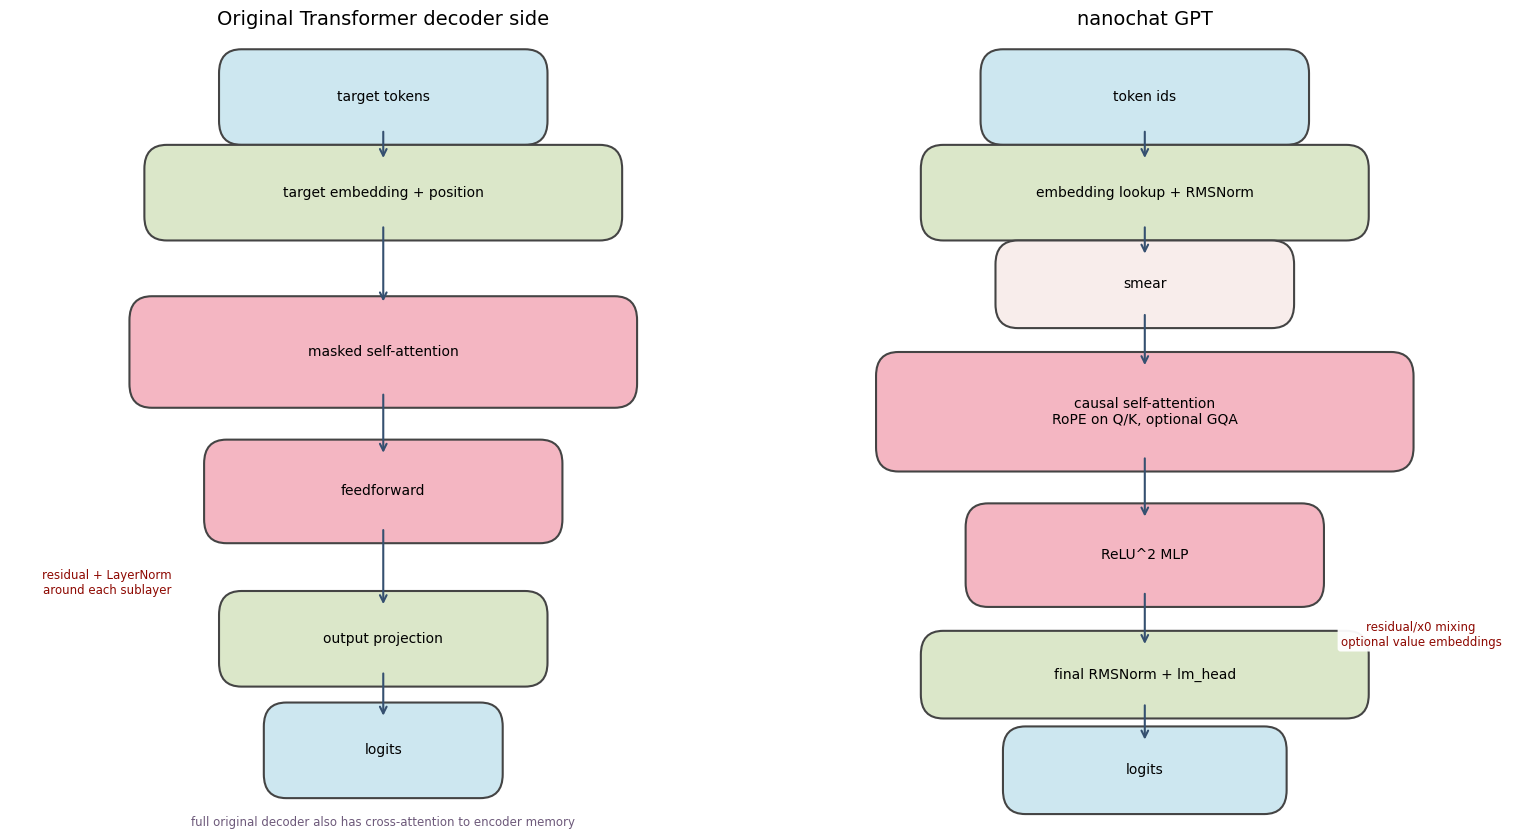

In [2]:
def add_box(ax, x, y, w, h, text, facecolor="#f7c8d0", fontsize=10):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.5,
        edgecolor="#444",
        facecolor=facecolor,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        multialignment="center",
        linespacing=1.2,
    )
    return patch


def add_arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=12,
            linewidth=1.5,
            color="#355070",
        )
    )


def add_note(ax, x, y, text, color="#8d0801", fontsize=8.5):
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.95),
        multialignment="center",
        linespacing=1.15,
    )


fig, axes = plt.subplots(1, 2, figsize=(15.5, 8.5))
fig.subplots_adjust(wspace=0.28)

# Original Transformer decoder side
ax = axes[0]
ax.set_title("Original Transformer decoder side", fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
add_box(ax, 0.30, 0.88, 0.40, 0.08, "target tokens", facecolor="#cde7f0")
add_box(ax, 0.20, 0.76, 0.60, 0.08, "target embedding + position", facecolor="#dbe7c9")
add_box(ax, 0.18, 0.55, 0.64, 0.10, "masked self-attention", facecolor="#f4b6c2")
add_box(ax, 0.28, 0.38, 0.44, 0.09, "feedforward", facecolor="#f4b6c2")
add_box(ax, 0.30, 0.20, 0.40, 0.08, "output projection", facecolor="#dbe7c9")
add_box(ax, 0.36, 0.06, 0.28, 0.08, "logits", facecolor="#cde7f0")
for y1, y2 in [(0.88, 0.84), (0.76, 0.66), (0.55, 0.47), (0.38, 0.28), (0.20, 0.14)]:
    add_arrow(ax, 0.5, y1, 0.5, y2)
add_note(ax, 0.13, 0.31, "residual + LayerNorm\naround each sublayer")
ax.text(
    0.5,
    0.01,
    "full original decoder also has cross-attention to encoder memory",
    ha="center",
    va="center",
    fontsize=8.5,
    color="#6d597a",
)

# nanochat GPT
ax = axes[1]
ax.set_title("nanochat GPT", fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
add_box(ax, 0.30, 0.88, 0.40, 0.08, "token ids", facecolor="#cde7f0")
add_box(ax, 0.22, 0.76, 0.56, 0.08, "embedding lookup + RMSNorm", facecolor="#dbe7c9")
add_box(ax, 0.32, 0.65, 0.36, 0.07, "smear", facecolor="#f8edeb")
add_box(ax, 0.16, 0.47, 0.68, 0.11, "causal self-attention\nRoPE on Q/K, optional GQA", facecolor="#f4b6c2")
add_box(ax, 0.28, 0.30, 0.44, 0.09, "ReLU^2 MLP", facecolor="#f4b6c2")
add_box(ax, 0.22, 0.16, 0.56, 0.07, "final RMSNorm + lm_head", facecolor="#dbe7c9")
add_box(ax, 0.33, 0.04, 0.34, 0.07, "logits", facecolor="#cde7f0")
for y1, y2 in [(0.88, 0.84), (0.76, 0.72), (0.65, 0.58), (0.47, 0.39), (0.30, 0.23), (0.16, 0.11)]:
    add_arrow(ax, 0.5, y1, 0.5, y2)
add_note(ax, 0.87, 0.245, "residual/x0 mixing\noptional value embeddings")

plt.tight_layout()
plt.show()

## Step 4. Important `nanochat` changes from the original Transformer decoder side

This is the section to slow down on. The model is still recognizably a transformer:

`token ids -> embeddings -> attention -> MLP -> logits`

But `nanochat/gpt.py` changes several parts of that path. The important ones are:

| Change | Short meaning | Where it matters |
|---|---|---|
| RoPE | position is applied by rotating Q/K inside attention | attention knows order without adding a position vector to embeddings |
| RMSNorm | normalize by vector size, not by subtracting mean like LayerNorm | simpler normalization before attention/MLP |
| GQA | more query heads than key/value heads | cheaper KV cache and attention memory during inference |
| ReLU^2 MLP | use `relu(x).square()` in the feedforward block | stronger nonlinearity than plain ReLU |
| `smear` | learned previous-token mixing before the block stack | gives the model a cheap local bigram-like signal |

A good mental model:

`original decoder block skeleton` stays, but several implementation choices are modernized for GPT training/inference.

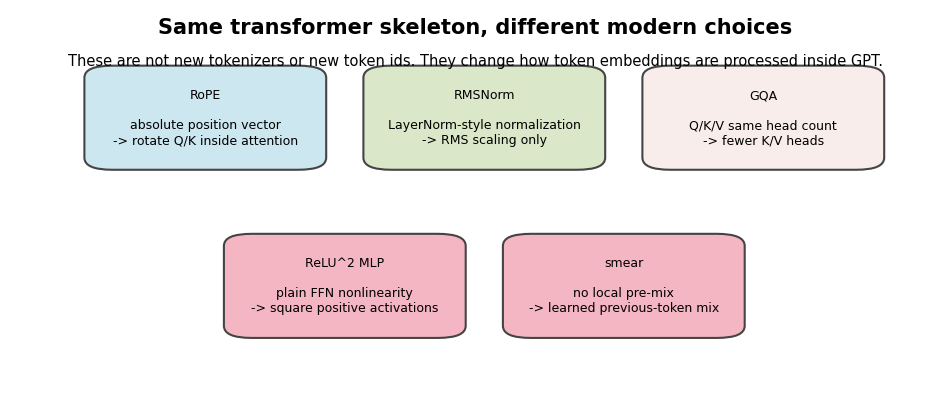

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

changes = [
    ("RoPE", "absolute position vector\n-> rotate Q/K inside attention", 0.10, 0.62, "#cde7f0"),
    ("RMSNorm", "LayerNorm-style normalization\n-> RMS scaling only", 0.40, 0.62, "#dbe7c9"),
    ("GQA", "Q/K/V same head count\n-> fewer K/V heads", 0.70, 0.62, "#f8edeb"),
    ("ReLU^2 MLP", "plain FFN nonlinearity\n-> square positive activations", 0.25, 0.20, "#f4b6c2"),
    ("smear", "no local pre-mix\n-> learned previous-token mix", 0.55, 0.20, "#f4b6c2"),
]

for title, desc, x, y, color in changes:
    add_box(ax, x, y, 0.22, 0.22, f"{title}\n\n{desc}", facecolor=color, fontsize=9)

ax.text(0.5, 0.94, "Same transformer skeleton, different modern choices", ha="center", fontsize=15, weight="bold")
ax.text(0.5, 0.86, "These are not new tokenizers or new token ids. They change how token embeddings are processed inside GPT.", ha="center", fontsize=10.5)
plt.show()

### 4.1 RoPE: position enters attention, not the embedding stream

In the original Transformer, position is added directly to the token embedding:

`embedding_with_position = token_embedding + positional_encoding[position]`

In `nanochat`, there is no learned or sinusoidal positional embedding added to `x`. Instead:

1. token ids become embeddings
2. attention projects embeddings into Q, K, V
3. RoPE rotates Q and K by a position-dependent angle
4. attention compares the rotated Q/K vectors

Why this matters: attention scores become position-aware, but the residual stream is not permanently changed by adding a separate position vector.

Original Transformer-style absolute position:
  token embedding        = [1.0, 0.0, 1.0, 0.0]
  position vector pos=1  = [0.8414709568023682, 0.5403023362159729, 0.009999833069741726, 0.9999499917030334]
  embedding + position   = [1.8414709568023682, 0.5403023362159729, 1.0099998712539673, 0.9999499917030334]

nanochat-style RoPE:
  query before RoPE      = [1.0, 0.0, 1.0, 0.0]
  RoPE(query, pos=0)     = [1.0, 0.0, 1.0, 0.0]
  RoPE(query, pos=1)     = [1.3817732334136963, 0.0, -0.30116862058639526, 0.0]

Notice: RoPE changes Q/K for attention. It is not a new token id and not a tokenizer change.


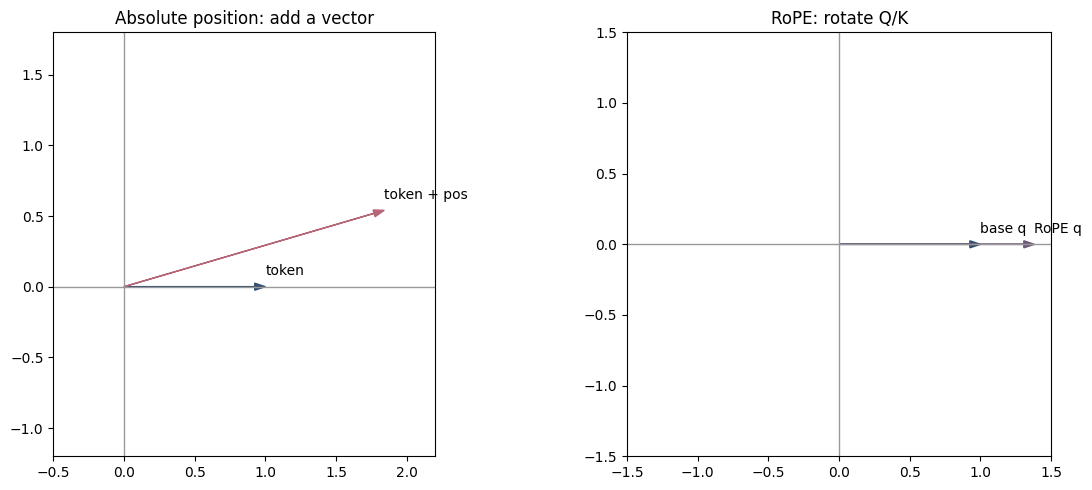

In [4]:
def sinusoidal_row(pos, d_model=4):
    pe = torch.zeros(d_model, dtype=torch.float32)
    div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
    pe[0::2] = torch.sin(torch.tensor(float(pos)) * div_term)
    pe[1::2] = torch.cos(torch.tensor(float(pos)) * div_term)
    return pe


def rope_cos_sin(seq_len, head_dim, base=100000):
    channel_range = torch.arange(0, head_dim, 2, dtype=torch.float32)
    inv_freq = 1.0 / (base ** (channel_range / head_dim))
    t = torch.arange(seq_len, dtype=torch.float32)
    freqs = torch.outer(t, inv_freq)
    cos = freqs.cos()[None, :, None, :]
    sin = freqs.sin()[None, :, None, :]
    return cos, sin


token_embedding = torch.tensor([1.0, 0.0, 1.0, 0.0], dtype=torch.float32)
absolute_pos_1 = sinusoidal_row(1, d_model=4)
embedding_plus_position = token_embedding + absolute_pos_1

query_before_rope = token_embedding.view(1, 1, 1, 4)
cos, sin = rope_cos_sin(seq_len=2, head_dim=4)
query_pos_0 = apply_rotary_emb(query_before_rope, cos[:, 0:1], sin[:, 0:1])[0, 0, 0]
query_pos_1 = apply_rotary_emb(query_before_rope, cos[:, 1:2], sin[:, 1:2])[0, 0, 0]

print("Original Transformer-style absolute position:")
print("  token embedding        =", token_embedding.tolist())
print("  position vector pos=1  =", absolute_pos_1.tolist())
print("  embedding + position   =", embedding_plus_position.tolist())
print()
print("nanochat-style RoPE:")
print("  query before RoPE      =", token_embedding.tolist())
print("  RoPE(query, pos=0)     =", query_pos_0.tolist())
print("  RoPE(query, pos=1)     =", query_pos_1.tolist())
print()
print("Notice: RoPE changes Q/K for attention. It is not a new token id and not a tokenizer change.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.set_title("Absolute position: add a vector")
ax.axhline(0, color="#999", linewidth=1)
ax.axvline(0, color="#999", linewidth=1)
ax.arrow(0, 0, token_embedding[0].item(), token_embedding[1].item(), head_width=0.05, color="#355070", length_includes_head=True)
ax.arrow(0, 0, embedding_plus_position[0].item(), embedding_plus_position[1].item(), head_width=0.05, color="#b56576", length_includes_head=True)
ax.text(token_embedding[0].item(), token_embedding[1].item() + 0.08, "token")
ax.text(embedding_plus_position[0].item(), embedding_plus_position[1].item() + 0.08, "token + pos")
ax.set_xlim(-0.5, 2.2)
ax.set_ylim(-1.2, 1.8)
ax.set_aspect("equal")

ax = axes[1]
ax.set_title("RoPE: rotate Q/K")
ax.axhline(0, color="#999", linewidth=1)
ax.axvline(0, color="#999", linewidth=1)
ax.arrow(0, 0, token_embedding[0].item(), token_embedding[1].item(), head_width=0.05, color="#355070", length_includes_head=True)
ax.arrow(0, 0, query_pos_1[0].item(), query_pos_1[1].item(), head_width=0.05, color="#6d597a", length_includes_head=True)
ax.text(token_embedding[0].item(), token_embedding[1].item() + 0.08, "base q")
ax.text(query_pos_1[0].item(), query_pos_1[1].item() + 0.08, "RoPE q")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 4.2 RMSNorm: normalize scale without subtracting the mean

The original Transformer uses LayerNorm around sublayers.

`nanochat` uses this helper:

```python
def norm(x):
    return F.rms_norm(x, (x.size(-1),))
```

Beginner translation:

- LayerNorm says: “center this vector around zero, then scale it.”
- RMSNorm says: “do not center it; just scale it by its root-mean-square size.”

In this repo, RMSNorm also has no learned norm weight or bias. It is just a normalization operation.

In [5]:
sample = torch.tensor([[1.0, 2.0, 10.0]])

layernorm_like = (sample - sample.mean(dim=-1, keepdim=True)) / sample.std(dim=-1, keepdim=True, unbiased=False)
rmsnorm_like = sample / torch.sqrt(sample.square().mean(dim=-1, keepdim=True))

print("sample vector:")
print(sample)
print()
print("LayerNorm idea: subtract mean, then scale")
print(layernorm_like)
print(f"mean after LayerNorm-like step: {layernorm_like.mean().item():.4f}")
print()
print("RMSNorm idea: keep direction/offset, scale by RMS size")
print(rmsnorm_like)
print(f"mean after RMSNorm-like step: {rmsnorm_like.mean().item():.4f}")
print()
print("nanochat uses RMSNorm before attention, before MLP, and after embeddings/final block stack.")

sample vector:
tensor([[ 1.,  2., 10.]])

LayerNorm idea: subtract mean, then scale
tensor([[-0.8276, -0.5793,  1.4069]])
mean after LayerNorm-like step: -0.0000

RMSNorm idea: keep direction/offset, scale by RMS size
tensor([[0.1690, 0.3381, 1.6903]])
mean after RMSNorm-like step: 0.7325

nanochat uses RMSNorm before attention, before MLP, and after embeddings/final block stack.


### 4.3 GQA: many query heads can share fewer key/value heads

In standard multi-head attention, Q, K, and V usually have the same number of heads.

In `nanochat`, the config separates them:

- `n_head`: number of query heads
- `n_kv_head`: number of key/value heads

If `n_head = 4` and `n_kv_head = 2`, the model has 4 query heads but only 2 key/value heads. This is Grouped-Query Attention.

Why do this? During generation, the model stores K/V vectors in a KV cache. Fewer K/V heads means a smaller cache and cheaper inference, while keeping more query heads for expressiveness.

### 4.4 ReLU^2 MLP: the feedforward block squares positive activations

The MLP in `nanochat` is:

```python
x = self.c_fc(x)
x = F.relu(x).square()
x = self.c_proj(x)
```

So the nonlinearity is not just ReLU. It is:

- negative values become `0`
- positive values are squared
- larger positive activations become much larger

That gives the MLP a stronger “only fire when useful, but fire hard” behavior.

input:  [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ReLU:   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
ReLU^2: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 1.0, 2.25, 4.0, 6.25, 9.0]


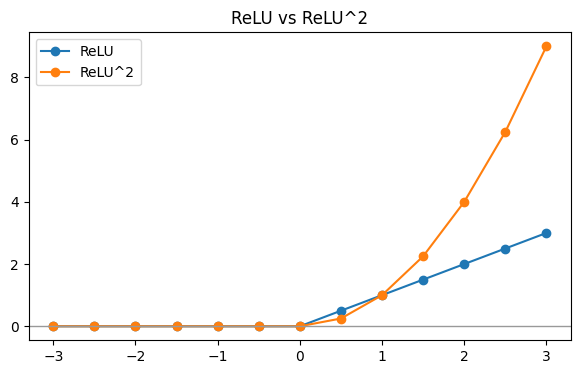

In [6]:
z = torch.linspace(-3, 3, 13)
relu_z = torch.relu(z)
relu2_z = relu_z.square()

print("input: ", z.tolist())
print("ReLU:  ", relu_z.tolist())
print("ReLU^2:", relu2_z.tolist())

plt.figure(figsize=(7, 4))
plt.plot(z, relu_z, marker="o", label="ReLU")
plt.plot(z, relu2_z, marker="o", label="ReLU^2")
plt.axhline(0, color="#999", linewidth=1)
plt.title("ReLU vs ReLU^2")
plt.legend()
plt.show()

### 4.5 `smear`: a cheap previous-token mix before the transformer blocks

`smear` is repo-specific. It is not part of the original Transformer.

The idea is simple:

```text
current token embedding += learned_gate * previous token embedding
```

The `gate` controls **how much** previous-token information is allowed in. In nanochat it is computed from the current token's first 24 embedding channels:

```python
gate = smear_lambda * sigmoid(smear_gate(current_token_embedding[:24]))
```

`smear_lambda` is the global strength. `smear_gate(...)` is the token-dependent part. `sigmoid(...)` keeps the token-dependent part between `0` and `1`.

Then the actual mixing is:

```text
x = [t0, t1, t2, t3]

new_t1 = t1 + gate1 * t0
new_t2 = t2 + gate2 * t1
new_t3 = t3 + gate3 * t2

result = [t0, new_t1, new_t2, new_t3]
```

So position 3 can receive a small learned amount of information from position 2 before the attention stack starts.

Why this can help: language has many local patterns. Examples: `New York`, `San Francisco`, `of the`, `machine learning`. Attention can learn these too, but `smear` gives the model a cheap local shortcut.

Important detail: in `init_weights()`, `smear_lambda` starts at `0`, so this feature starts disabled and training can learn whether to use it.

## Step 5. Build a tiny but valid `nanochat` GPT

Now we build a tiny model so the ideas above become actual tensor shapes.

Two repo-specific details matter here:

- `smear_gate` reads the first 24 embedding channels, so even this tiny model needs `n_embd >= 24`.
- we set `n_head=4` and `n_kv_head=2` on purpose, so GQA is visible in the shapes.

In [7]:
cfg = GPTConfig(
    sequence_len=8,
    vocab_size=32,
    n_layer=2,
    n_head=4,
    n_kv_head=2,
    n_embd=24,
    window_pattern="L",
)
model = GPT(cfg)
model.init_weights()
model.eval()

print(cfg)
print(f"window sizes: {model.window_sizes}")
print(f"parameter count: {sum(p.numel() for p in model.parameters()):,}")
print()
print("GQA setup:")
print(f"  query heads     n_head    = {cfg.n_head}")
print(f"  key/value heads n_kv_head = {cfg.n_kv_head}")
print(f"  head_dim                  = {cfg.n_embd // cfg.n_head}")

Padding vocab_size from 32 to 64 for efficiency
GPTConfig(sequence_len=8, vocab_size=32, n_layer=2, n_head=4, n_kv_head=2, n_embd=24, window_pattern='L')
window sizes: [(8, 0), (8, 0)]
parameter count: 16,566

GQA setup:
  query heads     n_head    = 4
  key/value heads n_kv_head = 2
  head_dim                  = 6


## Step 6. Inputs and targets

These are the tensors right before the model forward pass.

- `idx` is the input token-id tensor
- `targets` is the next-token tensor used for training loss
- `-1` means “ignore this target position”


In [8]:
idx = torch.tensor([[5, 9, 12, 7]], dtype=torch.int32)
targets = torch.tensor([[9, 12, 7, -1]], dtype=torch.int64)

print("idx:")
print(idx)
print(f"shape = {tuple(idx.shape)}, dtype = {idx.dtype}")
print()
print("targets:")
print(targets)
print(f"shape = {tuple(targets.shape)}, dtype = {targets.dtype}")
print()
print("Read this as next-token prediction:")
print("- given token 5, predict 9")
print("- given token 9, predict 12")
print("- given token 12, predict 7")
print("- target -1 means ignore this position in the loss")


idx:
tensor([[ 5,  9, 12,  7]], dtype=torch.int32)
shape = (1, 4), dtype = torch.int32

targets:
tensor([[ 9, 12,  7, -1]])
shape = (1, 4), dtype = torch.int64

Read this as next-token prediction:
- given token 5, predict 9
- given token 9, predict 12
- given token 12, predict 7
- target -1 means ignore this position in the loss


## Step 7. Token ids become embeddings

This is the first real transformation inside the model.
The integers in `idx` are used as lookup indices into `wte`, the token embedding table.


In [9]:
x_embed = model.transformer.wte(idx)
x = x_embed.to(COMPUTE_DTYPE)
x = norm(x)

print(f"x_embed.shape = {tuple(x_embed.shape)}, dtype = {x_embed.dtype}")
print(f"x.shape after norm = {tuple(x.shape)}, dtype = {x.dtype}")
print()
print("One token id becomes one embedding vector of length n_embd:")
print(f"  idx[0, 0] = {idx[0, 0].item()}")
print(f"  x_embed[0, 0, :8] = {x_embed[0, 0, :8]}")


x_embed.shape = (1, 4, 24), dtype = torch.float32
x.shape after norm = (1, 4, 24), dtype = torch.float32

One token id becomes one embedding vector of length n_embd:
  idx[0, 0] = 5
  x_embed[0, 0, :8] = tensor([-0.3066, -0.7595,  0.3802,  0.1292, -0.5850, -0.3266,  1.0699, -0.0962],
       grad_fn=<SliceBackward0>)


## Step 8. The block is familiar, but the surrounding logic is richer

If you only look at `Block.forward`, it is close to the transformer block shape you already know:

`norm -> attention -> residual add -> norm -> MLP -> residual add`

The differences we just discussed show up in specific places:

- RMSNorm is the `norm(x)` call before attention and before MLP.
- GQA changes the shapes of Q/K/V inside attention.
- RoPE is applied to Q and K after projection.
- ReLU^2 is inside the MLP.
- `smear` happens before the block stack, in `GPT.forward(...)`, not inside `Block.forward`.

The next cell walks through one mini forward pass and prints the shapes, so this stops being abstract.

In [10]:
T = idx.size(1)
cos_sin = model.cos[:, :T], model.sin[:, :T]

# Smear: mix previous token embedding into current position.
# smear_lambda starts at 0 after init_weights(), so the initial model has this disabled.
gate = model.smear_lambda.to(x.dtype) * torch.sigmoid(model.smear_gate(x[:, 1:, :24]))
x_after_smear = torch.cat([x[:, :1], x[:, 1:] + gate * x[:, :-1]], dim=1)

# Per-layer residual mixing before entering block 0.
x0 = x_after_smear
layer0_in = model.resid_lambdas[0].to(x.dtype) * x_after_smear + model.x0_lambdas[0].to(x.dtype) * x0

block0 = model.transformer.h[0]
ve0 = model.value_embeds["0"](idx.to(torch.long)).to(layer0_in.dtype) if "0" in model.value_embeds else None

attn_in = norm(layer0_in)
B, T, C = attn_in.shape
head_dim = cfg.n_embd // cfg.n_head
q = block0.attn.c_q(attn_in).view(B, T, cfg.n_head, head_dim)
k = block0.attn.c_k(attn_in).view(B, T, cfg.n_kv_head, head_dim)
v = block0.attn.c_v(attn_in).view(B, T, cfg.n_kv_head, head_dim)
q_rope = apply_rotary_emb(q, cos_sin[0], cos_sin[1])
k_rope = apply_rotary_emb(k, cos_sin[0], cos_sin[1])

attn_out = block0.attn(attn_in, ve0, cos_sin, model.window_sizes[0], kv_cache=None)
x_after_attn = layer0_in + attn_out

mlp_in = norm(x_after_attn)
mlp_hidden = block0.mlp.c_fc(mlp_in)
mlp_after_relu2 = torch.relu(mlp_hidden).square()
mlp_out = block0.mlp(mlp_in)
x_after_block0 = x_after_attn + mlp_out

print("smear:")
print(f"  smear_lambda = {model.smear_lambda.item():.4f}")
print(f"  gate.shape   = {tuple(gate.shape)}")
print(f"  x_after_smear.shape = {tuple(x_after_smear.shape)}")
print()
print("GQA attention shapes:")
print(f"  q.shape = {tuple(q.shape)}  # B, T, n_head, head_dim")
print(f"  k.shape = {tuple(k.shape)}  # B, T, n_kv_head, head_dim")
print(f"  v.shape = {tuple(v.shape)}  # B, T, n_kv_head, head_dim")
print(f"  q_rope.shape = {tuple(q_rope.shape)}")
print(f"  k_rope.shape = {tuple(k_rope.shape)}")
print()
print("MLP / ReLU^2:")
print(f"  mlp_hidden.shape      = {tuple(mlp_hidden.shape)}")
print(f"  mlp_after_relu2.shape = {tuple(mlp_after_relu2.shape)}")
print(f"  mlp_out.shape         = {tuple(mlp_out.shape)}")
print()
print("block output:")
print(f"  attn_out.shape       = {tuple(attn_out.shape)}")
print(f"  x_after_block0.shape = {tuple(x_after_block0.shape)}")
print(f"  has value embedding on layer 0? {ve0 is not None}")

smear:
  smear_lambda = 0.0000
  gate.shape   = (1, 3, 1)
  x_after_smear.shape = (1, 4, 24)

GQA attention shapes:
  q.shape = (1, 4, 4, 6)  # B, T, n_head, head_dim
  k.shape = (1, 4, 2, 6)  # B, T, n_kv_head, head_dim
  v.shape = (1, 4, 2, 6)  # B, T, n_kv_head, head_dim
  q_rope.shape = (1, 4, 4, 6)
  k_rope.shape = (1, 4, 2, 6)

MLP / ReLU^2:
  mlp_hidden.shape      = (1, 4, 96)
  mlp_after_relu2.shape = (1, 4, 96)
  mlp_out.shape         = (1, 4, 24)

block output:
  attn_out.shape       = (1, 4, 24)
  x_after_block0.shape = (1, 4, 24)
  has value embedding on layer 0? False


## Step 9. Full forward pass: from embeddings to logits and loss

At a high level, the full path is:

`idx -> embedding lookup -> norm -> smear -> transformer blocks -> final norm -> lm_head -> logits -> cross entropy loss`

That is the core loop you want to keep in your head while reading `gpt.py`.


In [11]:
with torch.no_grad():
    logits = model(idx)
    loss = model(idx, targets)

print(f"logits.shape = {tuple(logits.shape)}, dtype = {logits.dtype}")
print(f"loss = {float(loss):.6f}")
print()
print("Interpret logits as:")
print("- batch dimension")
print("- sequence position")
print("- score for every possible next token in the vocabulary")
print()
print("Example: logits for position 0, first 8 vocab entries:")
print(logits[0, 0, :8])


logits.shape = (1, 4, 32), dtype = torch.float32
loss = 3.469517

Interpret logits as:
- batch dimension
- sequence position
- score for every possible next token in the vocabulary

Example: logits for position 0, first 8 vocab entries:
tensor([-0.0028,  0.0012,  0.0005,  0.0032, -0.0088,  0.0049,  0.0037,  0.0028])


## Step 10. What is most different from the original Transformer decoder side?

The biggest architecture shifts are:

1. **Standalone GPT instead of a decoder that depends on an encoder.**
There is no encoder memory and no cross-attention.

2. **Causal self-attention only.**
A token can only use itself and earlier tokens, never future tokens.

3. **Position is handled inside attention.**
RoPE rotates Q/K instead of adding a position vector to token embeddings.

4. **The transformer block uses modern GPT choices.**
RMSNorm replaces LayerNorm-style normalization, GQA can reduce K/V heads, and the MLP uses ReLU^2.

5. **The repo adds extra modeling tricks around the block stack.**
`smear`, value embeddings, residual/x0 scaling, and backout are not tokenizer concepts. They are ways to process token embeddings inside the model.

6. **The training objective is language modeling.**
The model predicts the next token distribution at every position.

## Takeaways

- Tokenizer output is still just token ids. These architecture changes happen after ids become embeddings.
- The attention idea is still the same: Q, K, V, scaled dot-product, weighted values.
- `nanochat` differs from the original Transformer decoder side mainly through RoPE, RMSNorm, GQA, ReLU^2 MLP, and repo-specific extras like `smear`.
- `smear` is easiest to remember as a learned previous-token shortcut before the transformer blocks.
- When reading `gpt.py`, keep the full path in mind: `idx -> embedding -> norm -> smear -> blocks -> final norm -> lm_head -> logits`.